**Imports and Dataset Download:**

In [2]:
# Useful Imports

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

In [3]:
# Download the Zillow Housing Dataset

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


**PART 2 - Preliminary Data Exploration:**

Note: We divided the 55 features in the dataset into 1st_half and 2nd_half groups for easier analysis.

In [6]:
# Seperate Features 0-26

# Create list of column names
column_names_features_1st_half = df.columns.tolist()[0:27]

# Create a feature 0-26 subset of Zillow data frame
features_1st_half = df[column_names_features_1st_half]

**2.A - Characteristics of Each Feature:**

In [7]:
# Feature Names, Data Types, and Non-Null Counts

features_1st_half.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [27]:
# Make Table for Number of Unique Values by Column

np.set_printoptions(legacy = "1.25")

unique_rows = []

for c in column_names_features_1st_half:

  u = features_1st_half[c].nunique()

  unique_rows.append({"Column Name": c,
                      "Unique Value Count": u})

unique_counts = pd.DataFrame(unique_rows).sort_values("Unique Value Count").reset_index(drop = True)
unique_counts

,Column Name,Unique Value Count
0,decktypeid,1
1,hashottuborspa,1
2,buildingclasstypeid,2
3,fips,3
4,architecturalstyletypeid,5
5,fireplacecnt,5
6,airconditioningtypeid,5
7,heatingorsystemtypeid,10
8,buildingqualitytypeid,12
9,finishedsquarefeet13,13


In [29]:
# Make Table for Number of Null Counts by Column

null_rows = []

for c in column_names_features_1st_half:

  na = features_1st_half[c].isna().sum()
  nna = features_1st_half[c].notna().sum()
  napct = round(na / (na + nna) * 100, 2)

  null_rows.append({"Column Name": c,
                    "Null Count": na,
                    "Non-Null Count": nna,
                    "Null Percentage": napct})

null_counts = pd.DataFrame(null_rows).sort_values("Null Percentage", ascending = False).reset_index(drop = True)
null_counts

,Column Name,Null Count,Non-Null Count,Null Percentage
0,buildingclasstypeid,77598,15,99.98
1,finishedsquarefeet13,77571,42,99.95
2,basementsqft,77563,50,99.94
3,architecturalstyletypeid,77406,207,99.73
4,finishedsquarefeet6,77227,386,99.50
5,decktypeid,76999,614,99.21
6,hashottuborspa,76074,1539,98.02
7,finishedsquarefeet15,74586,3027,96.10
8,finishedfloor1squarefeet,71576,6037,92.22
9,finishedsquarefeet50,71576,6037,92.22


**2.A - Discussion:**

**1. Which features are categorical? **

*   For features 0-26, all features are numerical with the exception of `hashottuborspa` which is categorical.


**2. Are there any features which appear at first glance to be useless for the business purpose of this project and should be deleted? Give examples and describe your reasoning briefly.**

*   `parcelid` is likely not useful for this project as each example in the dataset has its own unique non-ordinal numerical identificaiton number which would have no impact on the assessed tax value of the property.

*   `fips`, which is a uniqie code to identify the county the property is in, will not be overly useful, and it becomes redundant given some of the other "region" features in the dataset that indicate property location.

*   `longitude` and `latitude` are unique for almost every sample listed and are too specific to use for determining the impact of the locaiton of a given property on the assessed tax value.

*   `calculatedbathnbr` and `fullbathcnt` likely become redundant with `bathroomcnt`, and we probably do not need all 3 of these features in our analysis.

*   The five `finishedsquarefeet` features are all redundant with `calculatedfinishedsquarefeet`. We will focus our analysis on the latter, since it represents the total number of finished square feet and has the fewest null values.


**3. Are there any features which appear to be useless because of the percentage of missing values? If so, give an example.**

*   Several  additional features will be useless due to the high number of null values. These include `buildingclasstypeid`, `basementsqft`, and `architecturalstyletypeid`.

**2.B - Exploratory Data Analysis (EDA) -- Feature-Level Visualization:**

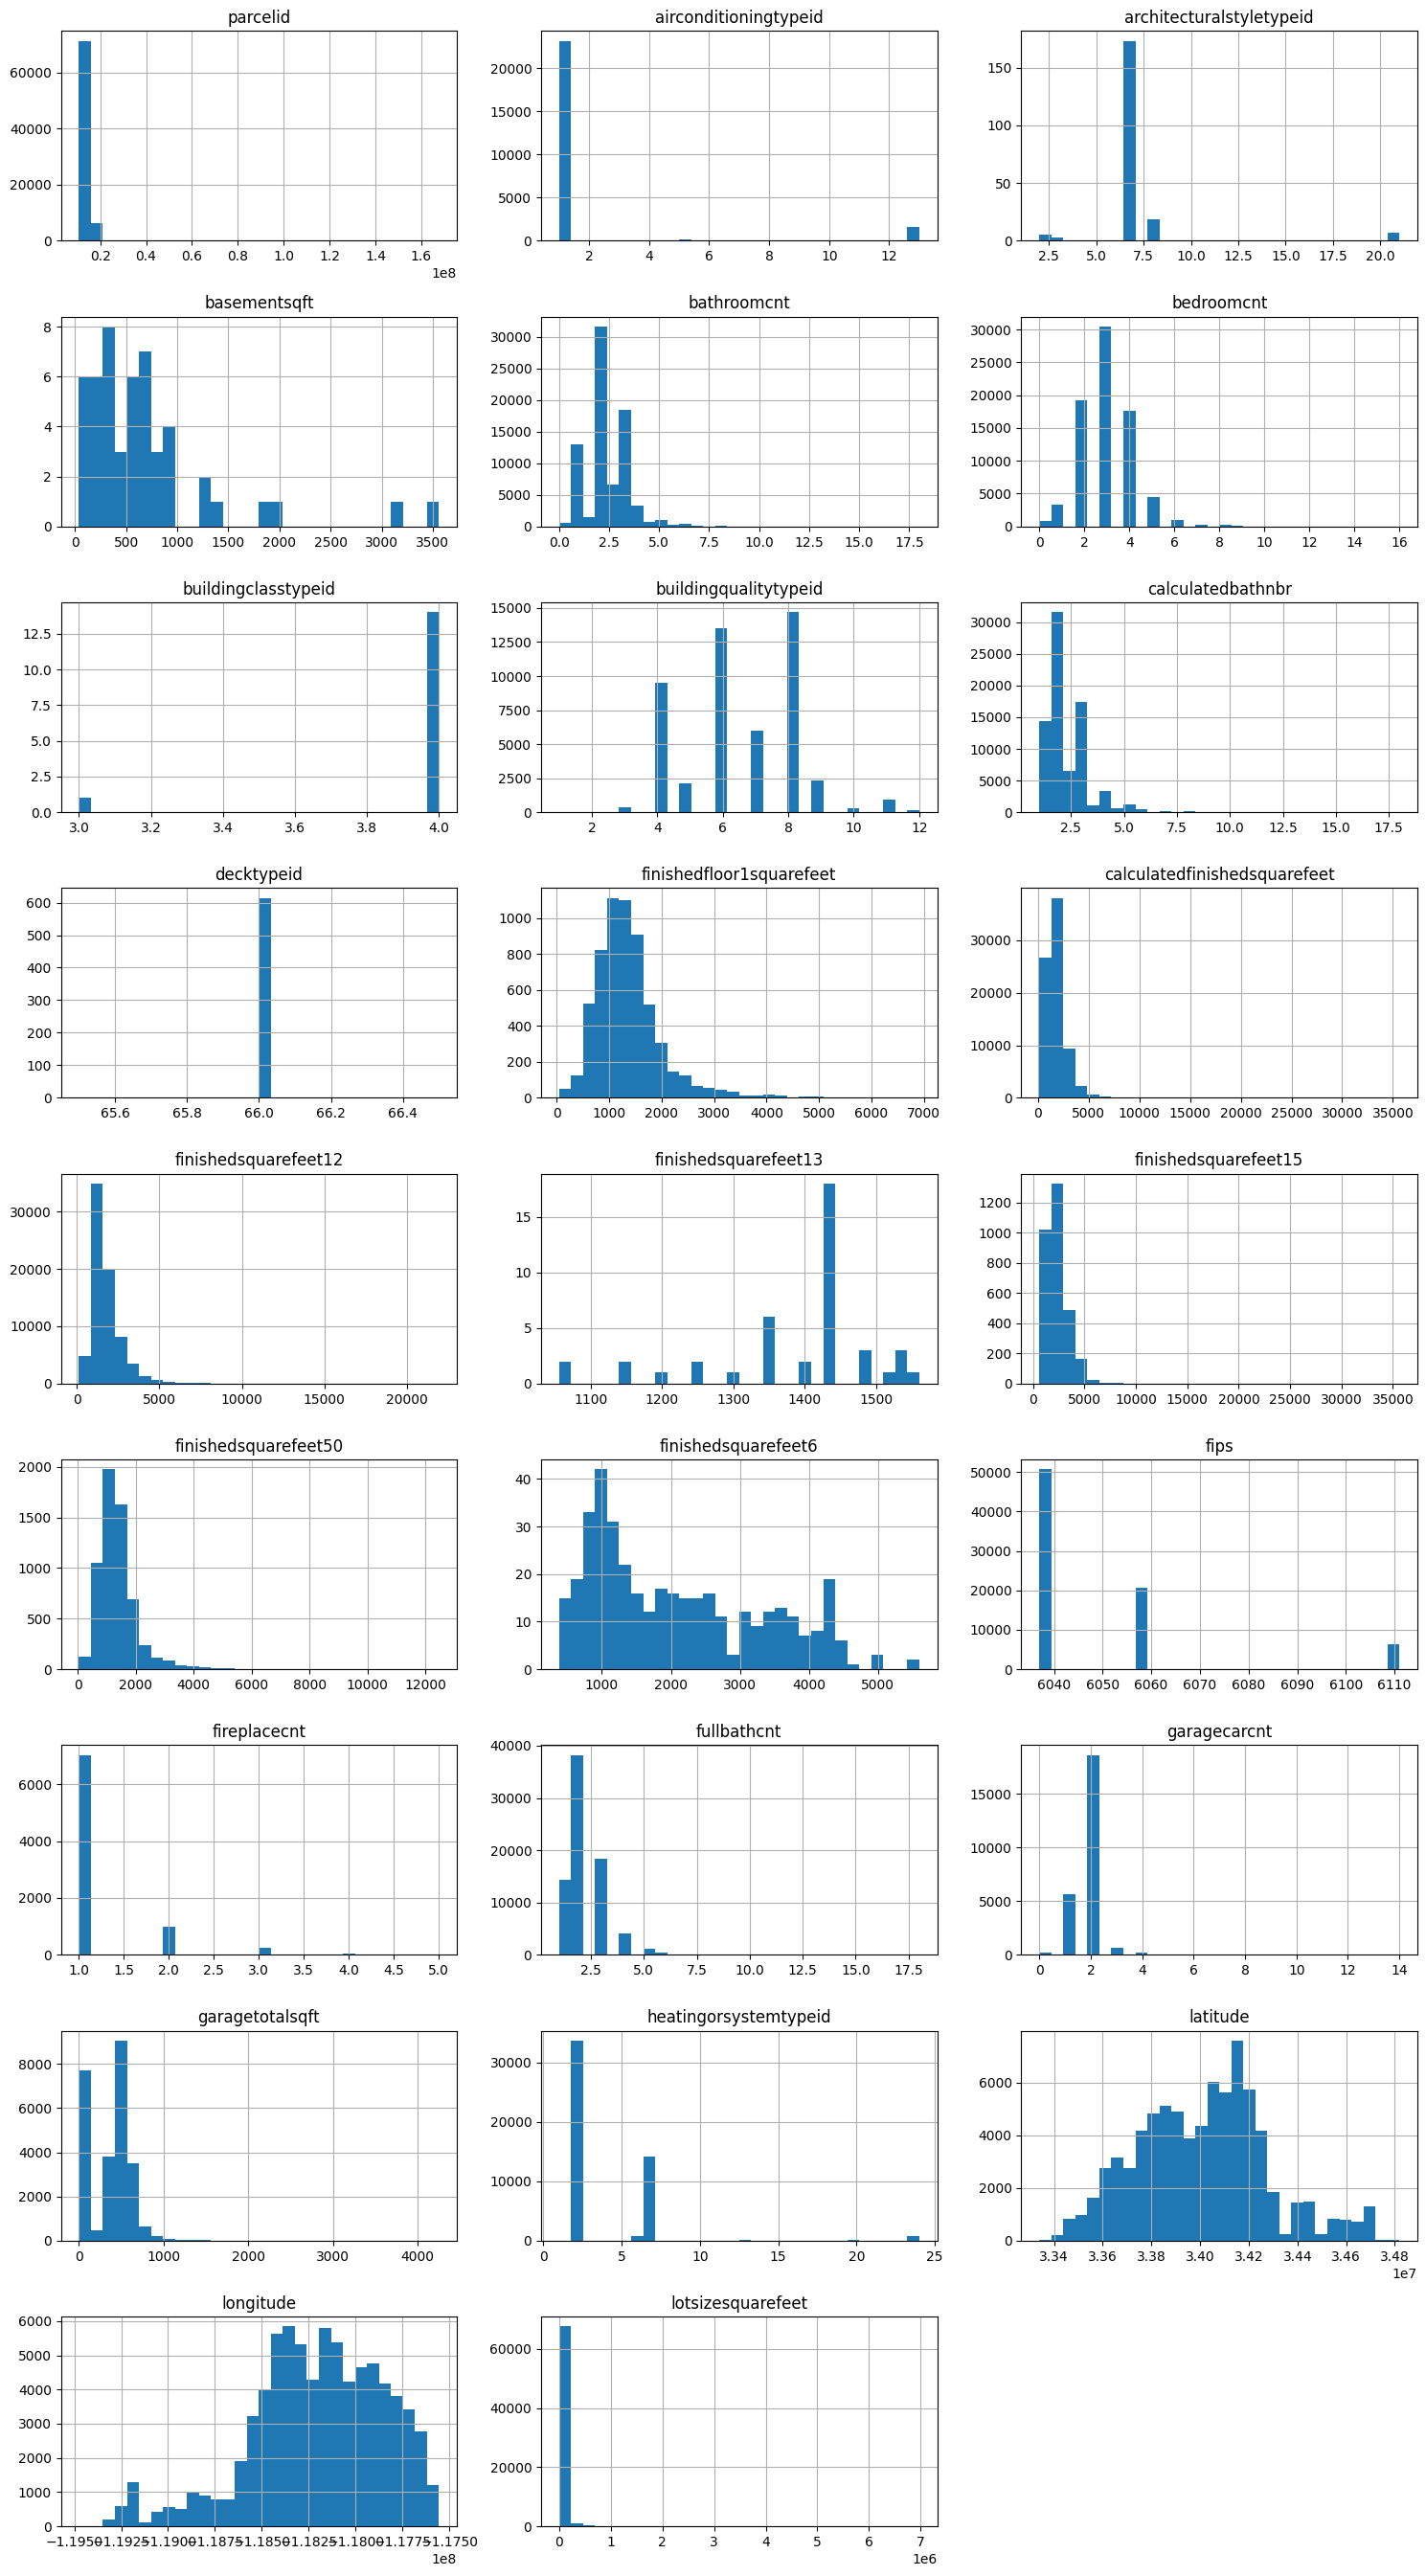

In [37]:
# Create Histograms of Features 0-26

features_1st_half.hist(figsize = (15, 27), layout = (-1, 3), bins = 30)
plt.tight_layout()
plt.show()

**Visualizations of 3 Interesting Features:**

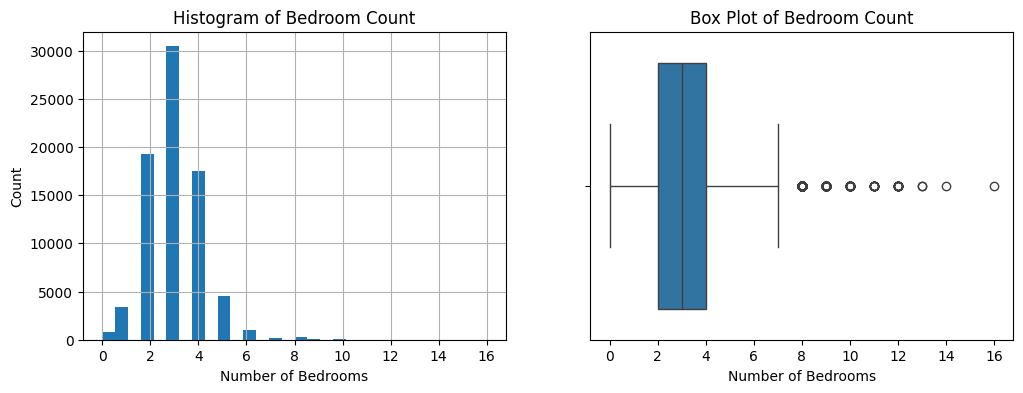

In [60]:
# 1. Histogram and Bar Plot of Bedroom Count

plt.subplots(1, 2, figsize = (12, 4))

plt.subplot(1, 2, 1)
features_1st_half["bedroomcnt"].hist(bins = 30)
plt.xlabel("Number of Bedrooms")
plt.ylabel("Count")
plt.title("Histogram of Bedroom Count")

plt.subplot(1, 2, 2)
sns.boxplot(data = features_1st_half, x = "bedroomcnt")
plt.xlabel("Number of Bedrooms")
plt.title("Box Plot of Bedroom Count")

None

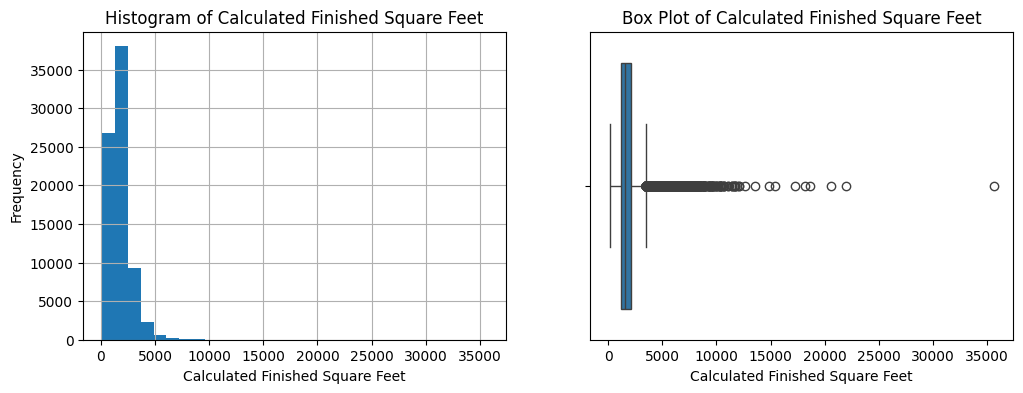

In [64]:
# 2. Histogram and Box Plot of Calculated Finished Sqaure Feet

plt.subplots(1, 2, figsize = (12, 4))

plt.subplot(1, 2, 1)
features_1st_half["calculatedfinishedsquarefeet"].hist(bins = 30)
plt.xlabel("Calculated Finished Square Feet")
plt.ylabel("Frequency")
plt.title("Histogram of Calculated Finished Square Feet")

plt.subplot(1, 2, 2)
sns.boxplot(data = features_1st_half, x = "calculatedfinishedsquarefeet")
plt.xlabel("Calculated Finished Square Feet")
plt.title("Box Plot of Calculated Finished Square Feet")

None

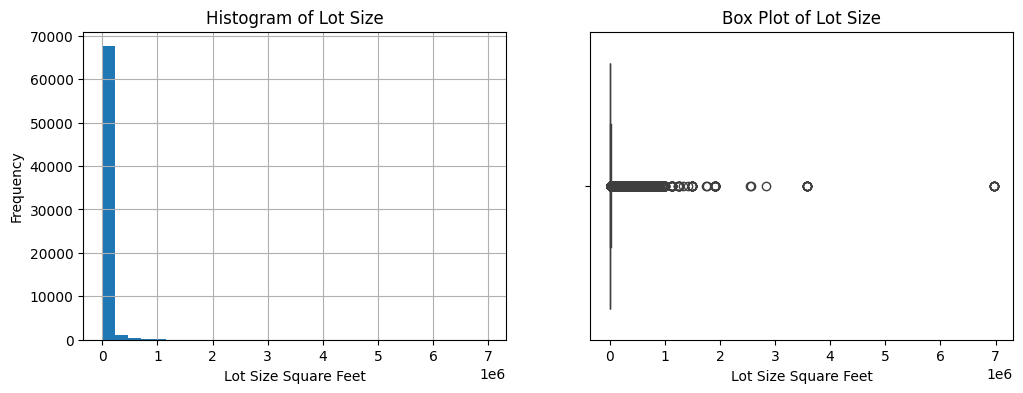

In [65]:
# 3. Histogram and Box Plot of Lot Size

plt.subplots(1, 2, figsize = (12, 4))

plt.subplot(1, 2, 1)
features_1st_half["lotsizesquarefeet"].hist(bins = 30)
plt.xlabel("Lot Size Square Feet")
plt.ylabel("Count")
plt.title("Histogram of Lot Size")

plt.subplot(1, 2, 2)
sns.boxplot(data = features_1st_half, x = "lotsizesquarefeet")
plt.xlabel("Lot Size Square Feet")
plt.title("Box Plot of Lot Size")

None

**Visualization of Target Variable:**

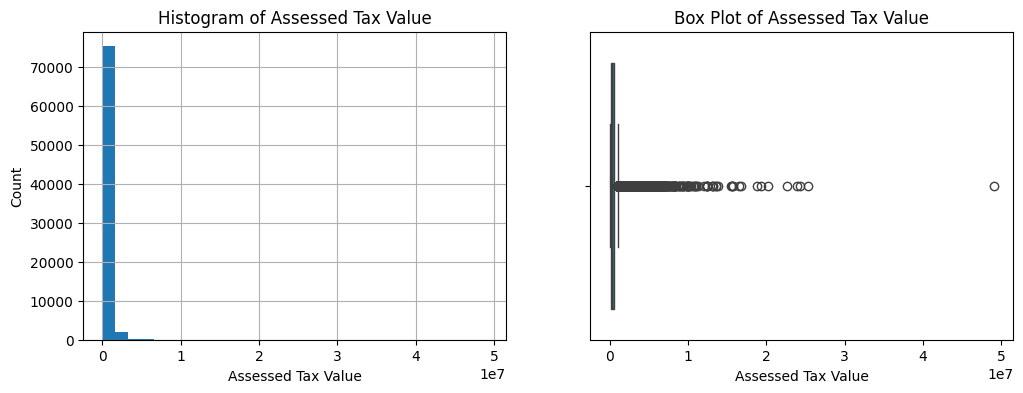

In [68]:
# Histogram and Box Plot of Target - Assessed Tax Value

plt.subplots(1, 2, figsize = (12, 4))

plt.subplot(1, 2, 1)
df["taxvaluedollarcnt"].hist(bins = 30)
plt.xlabel("Assessed Tax Value")
plt.ylabel("Count")
plt.title("Histogram of Assessed Tax Value")

plt.subplot(1, 2, 2)
sns.boxplot(data = df, x = "taxvaluedollarcnt")
plt.xlabel("Assessed Tax Value")
plt.title("Box Plot of Assessed Tax Value")

None

**2.B - Discussion:**

**1. What is the distribution (normal, exponential, etc.) if any?**

The histograms of the three features and the target variable shown above all indicate distributions that are significantly skewed to the right. The majority of the observations are stacked on the left, and all four variables have long tails to the right with a large number of high-valued outliers. If the outliers were removed, `bedroomcnt` would have an approximately normal distribution around a mean value of 3. Even with high outliers removed, it appears that `calculatedfinishedsqaurefeet`, `lotsizesquarefeet`, and the target variable `taxvaluedollarcnt` would all still be right-skewed.

**2. Any problems (e.g., outliers, any odd characteristics)?**

All four of the variables explored above have some significant high-valued outliers. It probably makes sense to select a threshold for dropping some of these outliers. If our goal with the dataset is to predict the assessed tax value, any model we build may not generalize as well to these outlier properties which are likely large luxury homes or mansions with a high number of bedrooms and significant lot size.

**3. Anything else interesting? Why did you choose it?**

We choose to explore these three features - `bedroomcnt`, `calculatedfinishedsqaurefeet`, and `lotsizesquarefeet` - as in theory they should all have an impact on assessed tax value, and all three had interesting shapes to their distributions. While all are skewed right, `bedroomcnt` appears to follow a normal distribution if the outliers are ignored.